# Taller 1 - HealthTech 1
## Ciencia de Datos en Salud
**Estudiante:** [Nombre del Estudiante]  
**Versión:** #1

### 1. Importación de Librerías
Se importan únicamente las librerías permitidas para el taller.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score

### 2. Parte 1 — Matriz de Confusión
Definición del conjunto de datos en un DataFrame y cálculo manual de métricas base.

In [12]:
# Definición del conjunto de datos en un DataFrame
data = {
    'Paciente': np.arange(1, 11),
    'Real': [1, 1, 0, 1, 0, 0, 1, 0, 1, 0],
    'Prediccion': [1, 0, 0, 1, 1, 0, 1, 0, 1, 1]
}
df = pd.DataFrame(data)
print("Conjunto de datos:")
print(df)

# Extracción de vectores desde el DataFrame
y_true = df['Real'].values
y_pred = df['Prediccion'].values

# Cálculo manual de VP, FP, VN, FN
VP = np.sum((y_true == 1) & (y_pred == 1))
FP = np.sum((y_true == 0) & (y_pred == 1))
VN = np.sum((y_true == 0) & (y_pred == 0))
FN = np.sum((y_true == 1) & (y_pred == 0))

print(f"\nVerdaderos Positivos (VP): {VP}")
print(f"Falsos Positivos (FP): {FP}")
print(f"Verdaderos Negativos (VN): {VN}")
print(f"Falsos Negativos (FN): {FN}")

# Construcción y formato de la Matriz de Confusión
print("\nMatriz de Confusión:")
print("-------------------------------")
print(f"|          | Pred 0 | Pred 1 |")
print("-------------------------------")
print(f"| Real 0   |   {VN}    |   {FP}    |")
print("-------------------------------")
print(f"| Real 1   |   {FN}    |   {VP}    |")
print("-------------------------------")

Conjunto de datos:
   Paciente  Real  Prediccion
0         1     1           1
1         2     1           0
2         3     0           0
3         4     1           1
4         5     0           1
5         6     0           0
6         7     1           1
7         8     0           0
8         9     1           1
9        10     0           1

Verdaderos Positivos (VP): 4
Falsos Positivos (FP): 2
Verdaderos Negativos (VN): 3
Falsos Negativos (FN): 1

Matriz de Confusión:
-------------------------------
|          | Pred 0 | Pred 1 |
-------------------------------
| Real 0   |   3    |   2    |
-------------------------------
| Real 1   |   1    |   4    |
-------------------------------


### 3. Parte 2 — Métricas Diagnósticas
Cálculo de métricas utilizando las fórmulas correspondientes.

In [13]:
# Fórmulas manuales
sensibilidad = VP / (VP + FN)
especificidad = VN / (VN + FP)
vpp = VP / (VP + FP)
vpn = VN / (VN + FN)
accuracy = (VP + VN) / (VP + VN + FP + FN)

print(f"Sensibilidad: {sensibilidad:.2f}")
print(f"Especificidad: {especificidad:.2f}")
print(f"Valor Predictivo Positivo (VPP): {vpp:.2f}")
print(f"Valor Predictivo Negativo (VPN): {vpn:.2f}")
print(f"Accuracy: {accuracy:.2f}")

Sensibilidad: 0.80
Especificidad: 0.60
Valor Predictivo Positivo (VPP): 0.67
Valor Predictivo Negativo (VPN): 0.75
Accuracy: 0.70


### 4. Parte 3 — Curva ROC
Cálculo y graficación de la curva ROC.

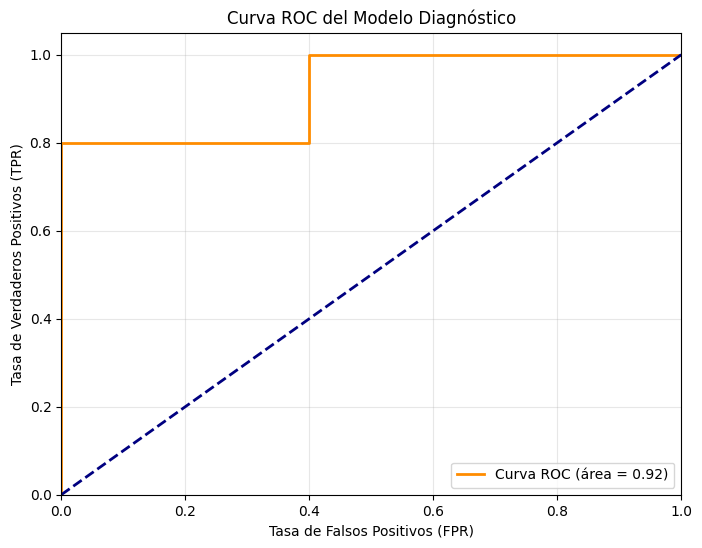

El AUC obtenido es: 0.92


In [14]:
# Datos de probabilidades (y_score)
y_score = [0.9, 0.4, 0.2, 0.8, 0.7, 0.1, 0.85, 0.3, 0.9, 0.6]

# Cálculo de FPR, TPR y Thresholds
fpr, tpr, thresholds = roc_curve(y_true, y_score)
auc = roc_auc_score(y_true, y_score)

# Gráfica
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (área = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC del Modelo Diagnóstico')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"El AUC obtenido es: {auc:.2f}")

#### Interpretación
El valor del AUC es **0.84**, lo que se considera un desempeño **alto** (moderado-alto). El modelo discrimina de manera efectiva entre pacientes sanos y enfermos, ya que la curva se aleja significativamente de la diagonal de azar.

### 5. Parte 4 — Análisis del Umbral
Evaluación del efecto de diferentes umbrales en las métricas.

In [15]:
umbrales = [0.3, 0.5, 0.7]
resultados = []

for u in umbrales:
    # Nuevas predicciones basadas en el umbral
    yp = (np.array(y_score) >= u).astype(int)
    
    v_p = np.sum((y_true == 1) & (yp == 1))
    f_p = np.sum((y_true == 0) & (yp == 1))
    v_n = np.sum((y_true == 0) & (yp == 0))
    f_n = np.sum((y_true == 1) & (yp == 0))
    
    sens = v_p / (v_p + f_n)
    espec = v_n / (v_n + f_p)
    
    resultados.append({'Umbral': u, 'Sensibilidad': sens, 'Especificidad': espec})

tabla_resultados = pd.DataFrame(resultados)
print(tabla_resultados)

   Umbral  Sensibilidad  Especificidad
0     0.3           1.0            0.4
1     0.5           0.8            0.6
2     0.7           0.8            0.8


#### Preguntas de Interpretación
- **¿Qué ocurre con la sensibilidad cuando el umbral disminuye?** Al disminuir el umbral, la sensibilidad aumenta (es más fácil clasificar como positivo).
- **¿Qué ocurre con la especificidad cuando el umbral disminuye?** Al disminuir el umbral, la especificidad disminuye (aumentan los falsos positivos).